In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import joblib
from scipy.sparse import load_npz
import numpy as np


data = joblib.load('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/Individual Project/TF-IDF&LogisticRegression/data/all_data.pkl')
x_train = data['x_train_tfidf']
x_test = data['x_test_tfidf']
y_train = data['y_train_enc']
y_test = data['y_test_enc']
tfidf = data['tfidf_defaults']
encoder = data['encoder']

In [7]:
#Logistic Regression Defaults

from sklearn.linear_model import LogisticRegression

# ============================================
# 2. DEFINISIKAN 3 SKENARIO
# ============================================

print("\n" + "="*60)
print(" 🔧 3 SKENARIO LOGISTIC REGRESSION")
print("="*60)

# Skenario A: Hanya C=0.1 (class_weight default=None)
lr_c01 = LogisticRegression(
    C=0.1,                    # Regularisasi lebih kuat
    class_weight=None,         # DEFAULT
    random_state=42,
    max_iter=1000
)

# Skenario B: Hanya class_weight='balanced' (C default=1.0)
lr_balanced = LogisticRegression(
    C=1.0,                     # DEFAULT
    class_weight='balanced',    # Menangani ketidakseimbangan kelas
    random_state=42,
    max_iter=1000
)

# Skenario C: Kombinasi keduanya (C=0.1 + balanced)
lr_combined = LogisticRegression(
    C=0.1,                     # Regularisasi lebih kuat
    class_weight='balanced',    # Menangani ketidakseimbangan kelas
    random_state=42,
    max_iter=1000
)

print("\n📋 Skenario A: Hanya C=0.1")
print(f"   • C = 0.1")
print(f"   • class_weight = None (default)")

print("\n📋 Skenario B: Hanya class_weight='balanced'")
print(f"   • C = 1.0 (default)")
print(f"   • class_weight = 'balanced'")

print("\n📋 Skenario C: Kombinasi C=0.1 + balanced")
print(f"   • C = 0.1")
print(f"   • class_weight = 'balanced'")


 🔧 3 SKENARIO LOGISTIC REGRESSION

📋 Skenario A: Hanya C=0.1
   • C = 0.1
   • class_weight = None (default)

📋 Skenario B: Hanya class_weight='balanced'
   • C = 1.0 (default)
   • class_weight = 'balanced'

📋 Skenario C: Kombinasi C=0.1 + balanced
   • C = 0.1
   • class_weight = 'balanced'


In [8]:
# ============================================
# 3. TRAINING DAN EVALUASI SEMUA SKENARIO
# ============================================

print("\n" + "="*60)
print(" 🚀 TRAINING DAN EVALUASI")
print("="*60)

results = []
models = {}

for name, model in [
    ("A: C=0.1", lr_c01),
    ("B: Balanced", lr_balanced),
    ("C: C=0.1 + Balanced", lr_combined)
]:
    print(f"\n📌 {name}")
    print("-" * 40)

    # Training
    model.fit(x_train, y_train)

    # Prediksi
    y_pred = model.predict(x_test)

        # Akurasi
    acc = accuracy_score(y_test, y_pred)
    print(f"   Akurasi: {acc:.4f} ({acc*100:.2f}%)")

    # Simpan hasil
    results.append({
        'Skenario': name,
        'C': model.C,
        'class_weight': str(model.class_weight),
        'Akurasi': acc
    })

    # Simpan model untuk analisis lebih lanjut
    models[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc
    }


 🚀 TRAINING DAN EVALUASI

📌 A: C=0.1
----------------------------------------
   Akurasi: 0.6198 (61.98%)

📌 B: Balanced
----------------------------------------
   Akurasi: 0.6143 (61.43%)

📌 C: C=0.1 + Balanced
----------------------------------------
   Akurasi: 0.6171 (61.71%)


In [10]:
# ============================================
# 4. TABEL PERBANDINGAN
# ============================================
import pandas as pd
print("\n" + "="*60)
print(" 📊 TABEL PERBANDINGAN")
print("="*60)

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))



 📊 TABEL PERBANDINGAN
           Skenario   C class_weight  Akurasi
           A: C=0.1 0.1         None 0.619835
        B: Balanced 1.0     balanced 0.614325
C: C=0.1 + Balanced 0.1     balanced 0.617080


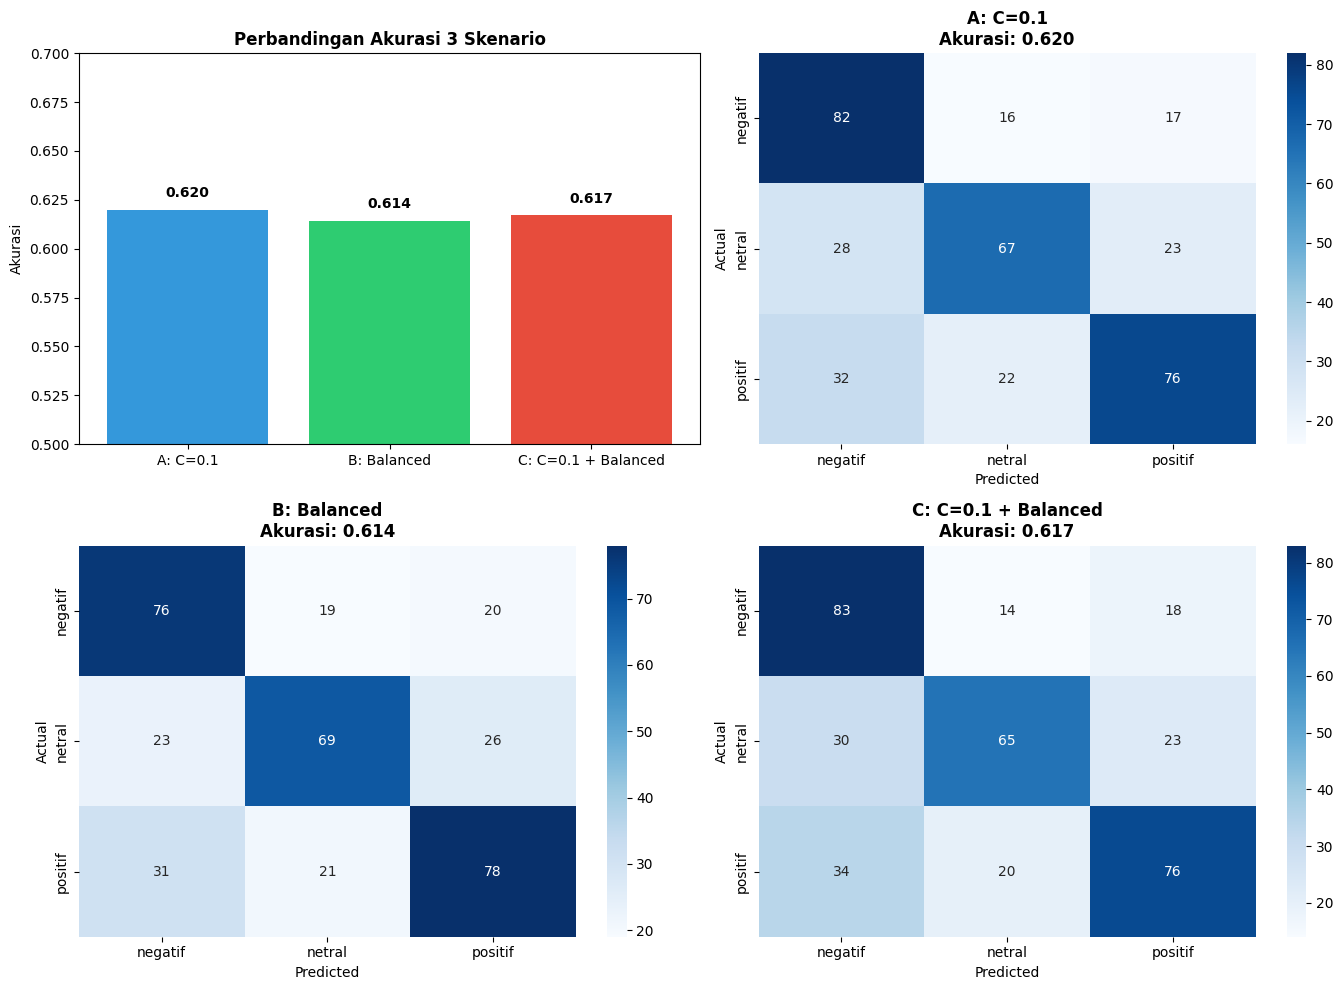

In [12]:
# ============================================
# 5. VISUALISASI PERBANDINGAN
# ============================================

# Plot 1: Perbandingan Akurasi
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
bars = plt.bar(df_results['Skenario'], df_results['Akurasi'],
               color=['#3498db', '#2ecc71', '#e74c3c'])
plt.ylim([0.5, 0.7])
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi 3 Skenario', fontweight='bold')

for bar, acc in zip(bars, df_results['Akurasi']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
# Plot 2,3,4: Confusion Matrix masing-masing skenario
for i, (name, data) in enumerate(models.items(), start=2):
    plt.subplot(2, 2, i)
    cm = confusion_matrix(y_test, data['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_,
                annot_kws={'size': 10})
    plt.title(f'{name}\nAkurasi: {data["accuracy"]:.3f}', fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('percobaan4_comparison.png', dpi=150)
plt.show()

In [ ]:
# ============================================
# 6. ANALISIS DETAIL PER SKENARIO
# ============================================

print("\n" + "="*60)
print(" 📈 ANALISIS DETAIL")
print("="*60)

for name, data in models.items():
    print(f"\n🔍 {name}")
    print("-" * 40)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, data['y_pred'],
                               target_names=encoder.classes_))

    # Hitung metrik per kelas
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, data['y_pred']
    )
    print("\nPerforma per Kelas:")
    for i, class_name in enumerate(encoder.classes_):
        print(f"   {class_name}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}")